# ANN Model - Predicting Antibacterial Activity Against E. coli

During office hours with Professor Markus, we confirmed that this is a classification problem and that an ANN (Artificial Neural Network) would be an appropriate model to try. We use a top 10% inhibition threshold to define active compounds, as this produced a cleaner classification boundary than the top 30% threshold used in the main notebook.

## Methods: Artificial Neural Network (ANN)

An Artificial Neural Network (ANN) is a machine learning model inspired 
by how the brain works. It learns by passing data through layers of 
connected nodes, where each node does a simple calculation and passes 
the result to the next layer. 

For our ANN model we used a simple feedforward ANN built with Keras 
(TensorFlow) with the following structure:
- **Input layer**: 13 numeric molecular features
- **Hidden layer**: 64 neurons with ReLU activation
- **Output layer**: 2 neurons with Softmax activation (active vs inactive)

We trained the model using the Adam optimizer with categorical cross-entropy loss over 100 epochs with a 20% validation split.

We chose the ANN because Professor Markus specifically suggested it during office hours as a good method to try for this dataset. The ANN can capture nonlinear relationships between molecular descriptors and antibacterial activity that simpler models like logistic regression cannot.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

### Morgan Fingerprinting

Adding 1024 Morgan fingerprint features to each compound. This showss structural patterns in each molecule which gives the ANN more information to work with than just the 13 numeric descriptors.

In [2]:
# We need `master_df`` for additional feature engineering after trying some models if needed.
master_df = pd.read_csv("ecoli_merged_master_4268.csv")

# Define a function that takes a SMILES string and returns a Morgan fingerprint

def get_morgan_fingerprint(smiles):
    
    # Convert the SMILES string into an RDKit molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    # If the molecule is invalid, return a list of 1024 zeros
    if mol is None:
        return [0] * 1024
    
    # Compute the Morgan fingerprint with radius=2 and nBits=1024
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
    fingerprint = generator.GetFingerprint(mol)
    
    # Convert the fingerprint to a list and return it
    return list(fingerprint)

# Apply the function to every SMILES string in master_df
morgan_list = master_df['SMILES'].apply(get_morgan_fingerprint).tolist()

# Convert the results into a dataframe with 1024 columns
morgan_df = pd.DataFrame(morgan_list, columns=[f'morgan_{i}' for i in range(1024)])

# Join the fingerprint dataframe back to master_df
master_df = pd.concat([master_df.reset_index(drop=True), morgan_df.reset_index(drop=True)], axis=1)

# Check the new shape of master_df
print(master_df.shape)

(4268, 1051)


### Sanity Check: Morgan Fingerprints

Making sure the fingerprints got added correctly.

In [13]:
# Sanity check, making sure Morgan fingerprints were added correctly
print("master_df shape after adding fingerprints:", master_df.shape)
print("Number of morgan columns:", sum(['morgan_' in col for col in master_df.columns]))

# Checking that no fingerprint rows are all zeros
morgan_cols = [col for col in master_df.columns if 'morgan_' in col]
zero_rows = (master_df[morgan_cols].sum(axis = 1) == 0).sum()
print("Rows where all 1024 fingerprint bits are zero:", zero_rows)

master_df shape after adding fingerprints: (4268, 1051)
Number of morgan columns: 1024
Rows where all 1024 fingerprint bits are zero: 0


### Feature Prep and Scaling

Pulling out the numeric columns, splitting INHIB_AVE off as our target, then doing the train/test split with stratify so both sets have the same ratio of active and inactive compounds. Then scaling everything with StandardScaler so the ANN doesn't get thrown off by features with different ranges.

In [3]:
# Define numeric feature columns explicitly for clarity.
numeric_feature_cols = master_df.select_dtypes(include=["number"]).columns.tolist()
print("All numeric columns:", numeric_feature_cols)

# Keep only numeric columns for machine learning.
numeric_df = master_df[numeric_feature_cols].copy()

X = numeric_df.drop(columns=["INHIB_AVE"])
y = numeric_df["INHIB_AVE"]

# Making the binary lables for stratification
y_binary = (y > y.quantile(0.7)).astype(int)

# Adding the stratify in order to make sure both training and test sets have the same ratio of inactive and active compounds
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=28, stratify=y_binary)

# Sanity check to verify stratify worked correctly
print("Training class balance:", y_binary[X_train.index].value_counts())
print("Test class balance:", y_binary[X_test.index].value_counts())

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("numeric_df shape:", numeric_df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("Numeric feature columns:", X.columns.tolist())

All numeric columns: ['NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'DMAX_AVE', 'MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED', 'MIC_VALUE_uM', 'morgan_0', 'morgan_1', 'morgan_2', 'morgan_3', 'morgan_4', 'morgan_5', 'morgan_6', 'morgan_7', 'morgan_8', 'morgan_9', 'morgan_10', 'morgan_11', 'morgan_12', 'morgan_13', 'morgan_14', 'morgan_15', 'morgan_16', 'morgan_17', 'morgan_18', 'morgan_19', 'morgan_20', 'morgan_21', 'morgan_22', 'morgan_23', 'morgan_24', 'morgan_25', 'morgan_26', 'morgan_27', 'morgan_28', 'morgan_29', 'morgan_30', 'morgan_31', 'morgan_32', 'morgan_33', 'morgan_34', 'morgan_35', 'morgan_36', 'morgan_37', 'morgan_38', 'morgan_39', 'morgan_40', 'morgan_41', 'morgan_42', 'morgan_43', 'morgan_44', 'morgan_45', 'morgan_46', 'morgan_47', 'morgan_48', 'morgan_49', 'morgan_50', 'morgan_51', 'morgan_52', 'morgan_53', 'morgan_54', 'morgan_55', 'morgan_56', 'morgan_57', 'morgan_58', 'morgan_59', 'morgan_60', 'morgan_61', 'morgan_62', 'morgan_63', 'morgan_64', 'mo

In [4]:
# Checking the current shape and columns of master_df before feature engineering
print(master_df.shape)
print(master_df.columns.tolist())

(4268, 1051)
['COADD_ID', 'COMPOUND_CODE', 'PROJECT_ID', 'LIBRARY_NAME', 'ASSAY_ID', 'ORGANISM', 'STRAIN', 'NASSAYS', 'INHIB_AVE', 'INHIB_STD', 'CONC', 'SMILES', 'DRVAL_TYPE', 'DRVAL_MEDIAN', 'DRVAL_UNIT', 'DMAX_AVE', 'MIC_OPERATOR', 'MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Rings', 'ArRings', 'QED', 'MIC_VALUE_uM', 'morgan_0', 'morgan_1', 'morgan_2', 'morgan_3', 'morgan_4', 'morgan_5', 'morgan_6', 'morgan_7', 'morgan_8', 'morgan_9', 'morgan_10', 'morgan_11', 'morgan_12', 'morgan_13', 'morgan_14', 'morgan_15', 'morgan_16', 'morgan_17', 'morgan_18', 'morgan_19', 'morgan_20', 'morgan_21', 'morgan_22', 'morgan_23', 'morgan_24', 'morgan_25', 'morgan_26', 'morgan_27', 'morgan_28', 'morgan_29', 'morgan_30', 'morgan_31', 'morgan_32', 'morgan_33', 'morgan_34', 'morgan_35', 'morgan_36', 'morgan_37', 'morgan_38', 'morgan_39', 'morgan_40', 'morgan_41', 'morgan_42', 'morgan_43', 'morgan_44', 'morgan_45', 'morgan_46', 'morgan_47', 'morgan_48', 'morgan_49', 'morgan_50', 'morgan_51', 'morgan_5

In [14]:
# Sanity check, making sure stratify worked and scaling looks right
print("Training class balance (top 30% threshold):")
print(y_binary[X_train.index].value_counts(normalize = True))
print("\nTesting the class balance (top 30% threshold):")
print(y_binary[X_test.index].value_counts(normalize = True))

# After scaling, training set should have mean close to 0 and std close to 1
print("\nThe mean of first scaled training column:", X_train_scaled.iloc[:, 0].mean())
print("Std of first scaled training column:", X_train_scaled.iloc[:, 0].std())

Training class balance (top 30% threshold):
INHIB_AVE
0    0.699766
1    0.300234
Name: proportion, dtype: float64

Testing the class balance (top 30% threshold):
INHIB_AVE
0    0.700234
1    0.299766
Name: proportion, dtype: float64

The mean of first scaled training column: -4.410193488798044e-15
Std of first scaled training column: 1.000146487952152


## Model 3: Simple Artificial Neural Network (ANN)

As our third model we are using Multi-Layer Perceptron Classifier (MLPClassifier)
This is a simpple feedforward neural network with one hidden layer that learns non-linear relationships between molecular descriptors and antibacterial activity. 

In [5]:
# Creating separate binary labels for ANN using top 10% threshold
# Keeping top 30% for other models, trying top 10% here to see if it improves results
ydummy_train_ann = (y_train > y_train.quantile(0.9)).astype(int)
ydummy_test_ann = (y_test > y_test.quantile(0.9)).astype(int)

# Sanity check, verify class balance with top 10% threshold
print("ANN Training class balance:", ydummy_train_ann.value_counts())
print("ANN Test class balance:", ydummy_test_ann.value_counts())

ANN Training class balance: INHIB_AVE
0    3072
1     342
Name: count, dtype: int64
ANN Test class balance: INHIB_AVE
0    768
1     86
Name: count, dtype: int64


### Version 1: Original ANN

First attempt at the ANN with no regularization. Simple Sequential model with 64 neurons in the hidden layer and softmax output. Training for 100 epochs to see how it does as a baseline.

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3985 - val_loss: 0.2796
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step - loss: 0.1250 - val_loss: 0.2638
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step - loss: 0.0707 - val_loss: 0.2858
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step - loss: 0.0504 - val_loss: 0.2937
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step - loss: 0.0432 - val_loss: 0.2988
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 930us/step - loss: 0.0356 - val_loss: 0.3213
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step - loss: 0.0330 - val_loss: 0.3301
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 0.0282 - val_loss: 0.3338
Epoch 9/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step - loss: 0.0237 - val_loss: 0.3495
Epoch 10/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step - loss: 0.0274 - val_loss: 0.3394
Epoch 11/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step - loss: 0.0226 - val_loss: 0.3355
Epoch 12/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 

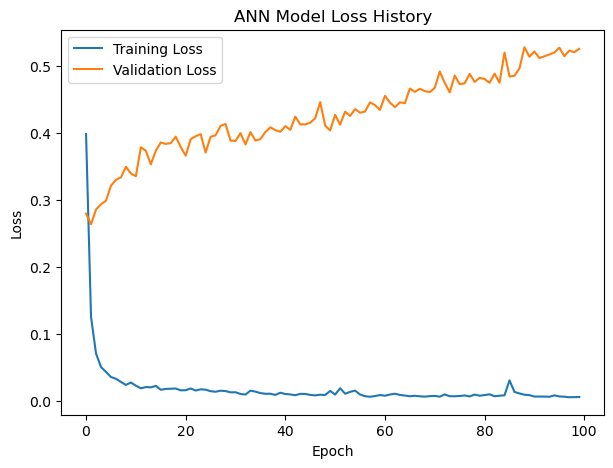

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step
Accuracy: 0.9262295081967213
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       768
           1       0.68      0.50      0.58        86

    accuracy                           0.93       854
   macro avg       0.81      0.74      0.77       854
weighted avg       0.92      0.93      0.92       854



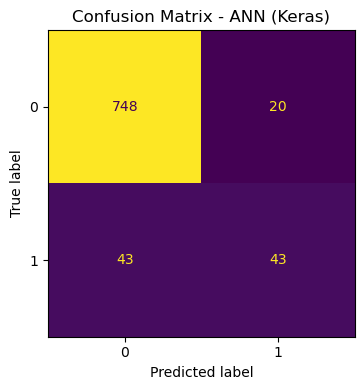

In [21]:
# Number of classes we have 2 (active and inactive)
NClasses = 2

# One-hot encode the binary labels for Keras, using lines from keras notebook from lecture 15
Y_train_oh = keras.utils.to_categorical(ydummy_train_ann, NClasses)
Y_test_oh = keras.utils.to_categorical(ydummy_test_ann, NClasses)
# Number of neurons in the hidden layer
Nneuron = 64

# Building the ANN model using My_Keras_Model function pattern
def My_Keras_Model_v1(Nneuron, NClasses):
    return keras.Sequential([
        # To help with the overfitting adding more dropout
        layers.Dense(Nneuron, activation='relu'),
        layers.Dense(NClasses, activation='softmax')
    ])
keras_model_v1 = My_Keras_Model_v1(Nneuron, NClasses)

# Compiling the model with adam optimizer and categorical_crossentropy loss
keras_model_v1.compile(optimizer='adam', loss='categorical_crossentropy')

# Number of training epochs
Nepochs = 100

# Training the model on scaled training data with validation_split=0.2
history = keras_model_v1.fit(X_train_scaled, Y_train_oh, epochs=Nepochs, validation_split=0.2)

# Plot the training and validation loss history
fig, ax = plt.subplots(figsize=(7,5))

# plot history['loss'] and history['val_loss']
ax.plot(history.history['loss'], label='Training Loss')
ax.plot(history.history['val_loss'], label='Validation Loss')

ax.set_title('ANN Model Loss History')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.show()

# Make predictions on test data
Predictions = keras_model_v1.predict(X_test_scaled)

# Convert probabilities to class labels using np.argmax
y_pred_ann = np.argmax(Predictions, axis=1)

# Printing the accuracy score
print("Accuracy:", accuracy_score(ydummy_test_ann, y_pred_ann))

# Printing the classfication report
print(classification_report(ydummy_test_ann, y_pred_ann))

# Ploting the confusion matrix
fig, ax = plt.subplots(figsize=(5,4))
cm = confusion_matrix(ydummy_test_ann, y_pred_ann)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix - ANN (Keras)')
plt.tight_layout()
plt.show()

In [22]:
# Sanity check, making sure top 10% threshold gives roughly 10% active in both splits
print("Training set active percentage:", round(ydummy_train_ann.mean() * 100, 2), "%")
print("Test set active percentage:", round(ydummy_test_ann.mean() * 100, 2), "%")
print("\nTraining counts:", ydummy_train_ann.value_counts().to_dict())
print("Test counts:", ydummy_test_ann.value_counts().to_dict())

Training set active percentage: 10.02 %
Test set active percentage: 10.07 %

Training counts: {0: 3072, 1: 342}
Test counts: {0: 768, 1: 86}


Using a top 10% inhibition threshold for the ANN improved accuracy to 93%.The model still shows some overfitting with validation loss diverging from training loss likely due to the class imbalance with only 10% active compounds. Despite this, the higher accuracy and improved F1 score suggest the top 10% threshold produces a more learnable classification boundary.

### Improving the ANN: L2 Regularization and Early Stopping

The first attempt with the ANN training showed clear overfitting, with validation loss diverging from training loss after a small number of epochs. To address this, we are going to apply two complementary regularization techniques.

The first is L2 regularization, covered in Module 10. L2 adds a penalty term to the loss function proportional to the squared magnitude of the model weights, not really letting the network from relying too heavily on any single feature. This is the same regularization principle as Professor Markus demonstrated for logistic regression in the WalkThroughL1L2 notebook, applied here to the hidden layer of the ANN through Keras's kernel_regularizer argument.

The second is early stopping, another regularization technique that was found in the Goodfellow et al. (2016, Chapter 7). Early stopping watches the validation loss while the model trains and stops things early if it stops improving for a set number of epochs, then rolls the model back to the weights from its best epoch. Like L2 regularization, early stopping helps with overfitting by keeping the model from getting too complex. L2 does this by penalizing large weights, while early stopping does this by stopping training before the model starts memorizing the training data.

**Reference:**  
Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press. Chapter 7: Regularization for Deep Learning. https://www.deeplearningbook.org/contents/regularization.html

Epoch 1/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.7735 - val_loss: 1.0933
Epoch 2/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7932 - val_loss: 0.7668
Epoch 3/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5280 - val_loss: 0.5882
Epoch 4/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3809 - val_loss: 0.4964
Epoch 5/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2945 - val_loss: 0.4178
Epoch 6/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2346 - val_loss: 0.3802
Epoch 7/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2008 - val_loss: 0.3514
Epoch 8/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1788 - val_loss: 0.3328
Epoch 9/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1591 - val_loss: 0.3358
Epoch 10/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1465 - val_loss: 0.3362
Epoch 11/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1431 - val_loss: 0.3178
Epoch 12/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1

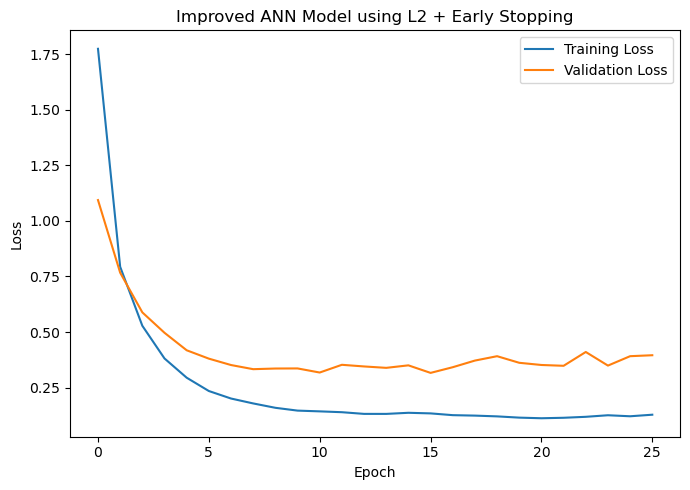

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 795us/step
Accuracy: 0.9402810304449649
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       768
           1       0.78      0.57      0.66        86

    accuracy                           0.94       854
   macro avg       0.87      0.78      0.81       854
weighted avg       0.94      0.94      0.94       854



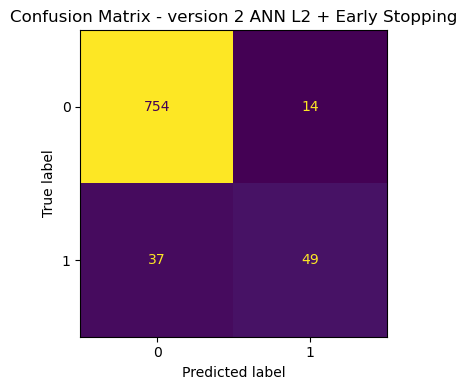

In [10]:
# Trying to build an improved ANN with L2 regularization on the hidden layer
def My_Keras_Model_v2(Nneuron, NClasses):
    return keras.Sequential([
        layers.Dense(Nneuron,  activation = 'relu',
                     kernel_regularizer = keras.regularizers.l2(0.01)),
        layers.Dense(NClasses, activation = 'softmax')
    ])

# Building and compiling 
keras_model_v2 = My_Keras_Model_v2(Nneuron, NClasses)
keras_model_v2.compile(optimizer = 'adam', loss = 'categorical_crossentropy')

# Defining the EarlyStopping callback to monitor validation loss
early_stopping = EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)

# Setting Nepochs higher since EarlyStopping will decide when to actually stop
Nepochs_v2 = 300

# Training the improved model with EarlyStopping callback
history_v2 = keras_model_v2.fit(X_train_scaled, Y_train_oh,
                                epochs = Nepochs_v2,
                                validation_split = 0.2,
                                callbacks = [early_stopping])

# Check what epoch training actually stopped at
print("Training stopped at epoch:", len(history_v2.history['loss']))

# Plot the training and validation loss history
fig, ax = plt.subplots(figsize = (7, 5))
ax.plot(history_v2.history['loss'], label = 'Training Loss')
ax.plot(history_v2.history['val_loss'], label = 'Validation Loss')
ax.set_title('Improved ANN Model using L2 + Early Stopping')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

# Making the predictions on the scaled test data
P_v2 = keras_model_v2.predict(X_test_scaled)

# Converting predicted probabilities to class labels using np.argmax
y_pred_ann_v2 = np.argmax(P_v2, axis = 1)

# Printing the accuracy score
print("Accuracy:", accuracy_score(ydummy_test_ann, y_pred_ann_v2))

# Printing the classification report
print(classification_report(ydummy_test_ann, y_pred_ann_v2))

# Plotting the confusion matrix
fig, ax = plt.subplots(figsize = (5, 4))
cm_v2 = confusion_matrix(ydummy_test_ann, y_pred_ann_v2)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_v2)
disp.plot(ax = ax, colorbar = False)
ax.set_title('Confusion Matrix Version 2 ANN L2 + Early Stopping')
plt.tight_layout()
plt.show()


v2 predicted class distribution:
{0: 791, 1: 63}

Actual test class distribution:
{0: 768, 1: 86}


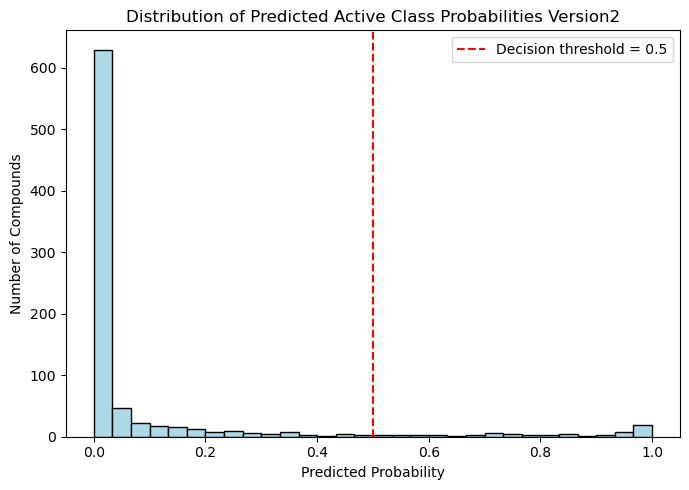

In [ ]:
# Sanity check, making sure version 2 model is predicting both classes and not just inactive
print("v2 predicted class distribution:")
print(pd.Series(y_pred_ann_v2).value_counts().to_dict())
print("\nActual test class distribution:")
print(ydummy_test_ann.value_counts().to_dict())

# Looking at the spread of predicted probabilities for the active class
fig, ax = plt.subplots(figsize = (7, 5))
ax.hist(P_v2[:, 1], bins = 30, edgecolor = 'black', color = 'lightblue')
ax.axvline(0.5, color = 'red', linestyle = '--', label = 'Decision threshold = 0.5')
ax.set_title('Distribution of Predicted Active Class Probabilities Version2')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Number of Compounds')
ax.legend()
plt.tight_layout()
plt.show()

The original ANN got 93% accuracy but it was clearly overfitting since the validation loss started pulling away from the training loss around epoch 10. Adding L2 regularization lambda = 0.01 and early stopping patience = 10 this helped fix both problems. Training stopped at epoch 26 and the model rolled back to epoch 16 where the validation loss was lowest. Accuracy went up a little from 93% to 94%, one of the best improvements was that recall on the active class went from 49% to 57%, which means the new model is doing a better job catching the actual active compounds instead of just guessing inactive for everything.

## Adding Class Weights to Address Class Imbalance

Even after L2 regularization and early stopping, recall on the active class was only 57%, meaning the model was still missing a lot of actually active compounds. Since only about 10% of compounds are active, the model just predicted inactive for most things. Class weighting tells the model to counts more mistakes on the active class about 9 times more than mistakes on the inactive class, which pushes it to actually try to learn the minority class instead of ignoring it. This is a similar idea to the over/undersampling approach from Module 3, but it adjusts the model's attention during training instead of changing the dataset itself.

**Reference:**  
TensorFlow. (n.d.). *Classification on imbalanced data*. https://www.tensorflow.org/tutorials/structured_data/imbalanced_data

Epoch 1/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.4045 - val_loss: 1.5698
Epoch 2/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3191 - val_loss: 1.2127
Epoch 3/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0223 - val_loss: 1.0548
Epoch 4/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step - loss: 0.8248 - val_loss: 0.9264
Epoch 5/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 910us/step - loss: 0.6909 - val_loss: 0.8000
Epoch 6/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 906us/step - loss: 0.6035 - val_loss: 0.7393
Epoch 7/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 970us/step - loss: 0.5179 - val_loss: 0.6886
Epoch 8/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step - loss: 0.4520 - val_loss: 0.6166
Epoch 9/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 917us/step - loss: 0.4323 - val_loss: 0.5936
Epoch 10/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - loss: 0.3715 - val_loss: 0.5443
Epoch 11/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 958us/step - loss: 0.3320 - val_loss: 0.5223
Epoch 12/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 916u

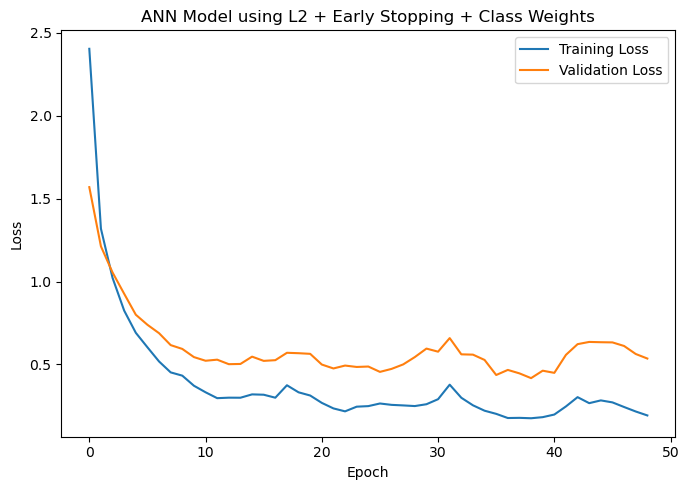

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 784us/step
Accuracy: 0.9215456674473068
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       768
           1       0.61      0.63      0.62        86

    accuracy                           0.92       854
   macro avg       0.78      0.79      0.79       854
weighted avg       0.92      0.92      0.92       854



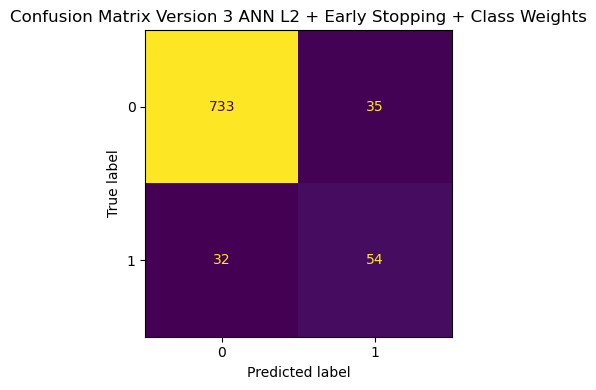

In [ ]:
# Trying again with class weights on top of L2 + Early Stopping 

# Computing class weights to address class imbalance
class_weights = {0: 1.0, 1: 9.0}

# Building and compiling a fresh model so weights start over
keras_model_v3 = My_Keras_Model_v2(Nneuron, NClasses)
keras_model_v3.compile(optimizer = 'adam', loss = 'categorical_crossentropy')

# Same EarlyStopping setup as before
early_stopping_v3 = EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)

# Same number of epochs as v2 to see if it improves with the class weights
Nepochs_v3 = 300

# Training with class_weight added this time
history_v3 = keras_model_v3.fit(X_train_scaled, Y_train_oh,
                                epochs = Nepochs_v3,
                                validation_split = 0.2,
                                callbacks = [early_stopping_v3],
                                class_weight = class_weights)

# Checking what epoch training actually stopped at
print("Training stopped at epoch:", len(history_v3.history['loss']))

# Plotting the training and validation loss history
fig, ax = plt.subplots(figsize = (7, 5))
ax.plot(history_v3.history['loss'], label = 'Training Loss')
ax.plot(history_v3.history['val_loss'], label = 'Validation Loss')
ax.set_title('ANN Model using L2 + Early Stopping + Class Weights')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

# Make predictions on the scaled test data
Predictions_v3 = keras_model_v3.predict(X_test_scaled)

# Convert predicted probabilities to class labels using np.argmax
y_pred_ann_v3 = np.argmax(Predictions_v3, axis = 1)

# Print the accuracy score
print("Accuracy:", accuracy_score(ydummy_test_ann, y_pred_ann_v3))

# Print the classification report
print(classification_report(ydummy_test_ann, y_pred_ann_v3))

# Plot the confusion matrix
fig, ax = plt.subplots(figsize = (5, 4))
cm_v3 = confusion_matrix(ydummy_test_ann, y_pred_ann_v3)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_v3)
disp.plot(ax = ax, colorbar = False)
ax.set_title('Confusion Matrix Version 3 ANN L2 + Early Stopping + Class Weights')
plt.tight_layout()
plt.show()

v3 predicted class distribution:
{0: 765, 1: 89}

Actual test class distribution:
{0: 768, 1: 86}


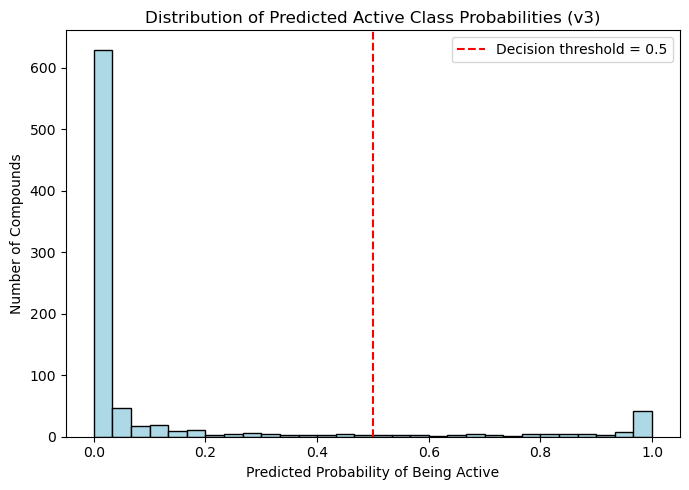

In [17]:
# Sanity check, making sure the model is predicting both classes and not just inactive
print("v3 predicted class distribution:")
print(pd.Series(y_pred_ann_v3).value_counts().to_dict())
print("\nActual test class distribution:")
print(ydummy_test_ann.value_counts().to_dict())

# Looking at the spread of predicted probabilities for the active class
fig, ax = plt.subplots(figsize = (7, 5))
ax.hist(Predictions_v3[:, 1], bins = 30, edgecolor = 'black', color = 'lightblue')
ax.axvline(0.5, color = 'red', linestyle = '--', label = 'Decision threshold = 0.5')
ax.set_title('Distribution of Predicted Active Class Probabilities (v3)')
ax.set_xlabel('Predicted Probability of Being Active')
ax.set_ylabel('Number of Compounds')
ax.legend()
plt.tight_layout()
plt.show()

## Trying a Stronger Class Weight

Version 3 improved recall to 63% but we wanted to see if pushing the class weight even higher would catch more active compounds. We tried weighting the active class 12 times heavier instead of 9.

Epoch 1/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.6744 - val_loss: 1.7065
Epoch 2/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.4345 - val_loss: 1.2270
Epoch 3/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0931 - val_loss: 1.0384
Epoch 4/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step - loss: 0.8893 - val_loss: 0.9266
Epoch 5/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 933us/step - loss: 0.7473 - val_loss: 0.8356
Epoch 6/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6538 - val_loss: 0.7668
Epoch 7/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5608 - val_loss: 0.6726
Epoch 8/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5075 - val_loss: 0.6411
Epoch 9/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step - loss: 0.4446 - val_loss: 0.5722
Epoch 10/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step - loss: 0.4119 - val_loss: 0.5642
Epoch 11/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 920us/step - loss: 0.4041 - val_loss: 0.5628
Epoch 12/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step

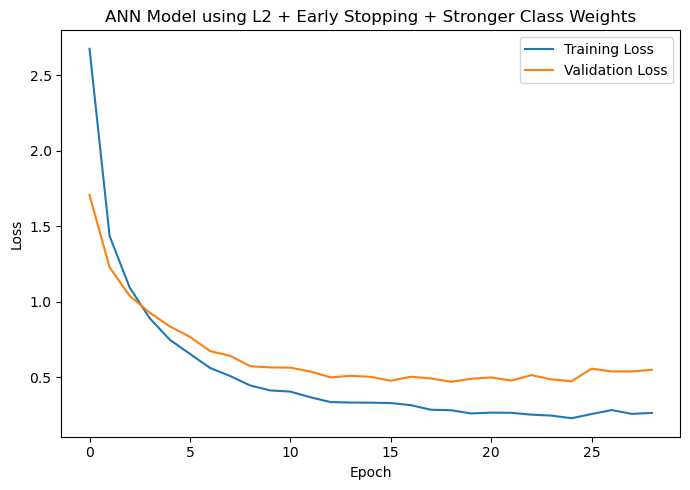

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step
Accuracy: 0.9086651053864169
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       768
           1       0.54      0.62      0.58        86

    accuracy                           0.91       854
   macro avg       0.75      0.78      0.76       854
weighted avg       0.91      0.91      0.91       854



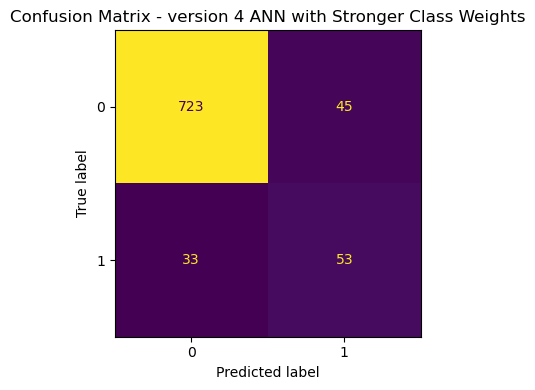

In [12]:
# Same setup as v3 but with a stronger class weight on the active class
class_weights_v4 = {0: 1.0, 1: 12.0}

# Building and compiling a fresh model so weights start over
keras_model_v4 = My_Keras_Model_v2(Nneuron, NClasses)
keras_model_v4.compile(optimizer = 'adam', loss = 'categorical_crossentropy')

# Same as the EarlyStopping setup as before
early_stopping_v4 = EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)

# Same number of epochs
Nepochs_v4 = 300

# Training with the stronger class weights
history_v4 = keras_model_v4.fit(X_train_scaled, Y_train_oh,
                                epochs = Nepochs_v4,
                                validation_split = 0.2,
                                callbacks = [early_stopping_v4],
                                class_weight = class_weights_v4)

# Checking  what epoch training actually stopped at
print("Training stopped at epoch:", len(history_v4.history['loss']))

# Plotting the training and validation loss history
fig, ax = plt.subplots(figsize = (7, 5))
ax.plot(history_v4.history['loss'], label = 'Training Loss')
ax.plot(history_v4.history['val_loss'], label = 'Validation Loss')
ax.set_title('ANN Model using L2 + Early Stopping + Stronger Class Weights')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

# Making the predictions on the scaled test data
Prediction_v4 = keras_model_v4.predict(X_test_scaled)

# Convert predicted probabilities to class labels using np.argmax
y_pred_ann_v4 = np.argmax(Prediction_v4, axis = 1)

# Print the accuracy score
print("Accuracy:", accuracy_score(ydummy_test_ann, y_pred_ann_v4))

# Print the classification report
print(classification_report(ydummy_test_ann, y_pred_ann_v4))

# Plot the confusion matrix
fig, ax = plt.subplots(figsize = (5, 4))
cm_v4 = confusion_matrix(ydummy_test_ann, y_pred_ann_v4)
disp = ConfusionMatrixDisplay(confusion_matrix = cm_v4)
disp.plot(ax = ax, colorbar = False)
ax.set_title('Confusion Matrix - version 4 ANN with Stronger Class Weights')
plt.tight_layout()
plt.show()

v4 predicted class distribution:
{0: 756, 1: 98}

Actual test class distribution:
{0: 768, 1: 86}


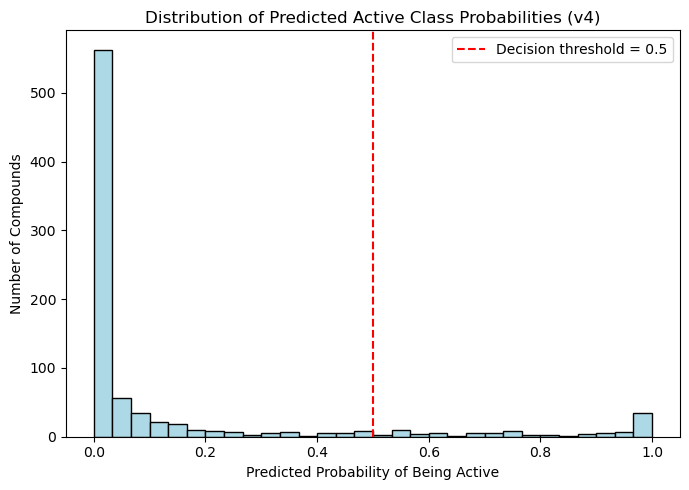

In [20]:
# Sanity check, making sure version 4 model with stronger class weights is predicting both classes
print("v4 predicted class distribution:")
print(pd.Series(y_pred_ann_v4).value_counts().to_dict())
print("\nActual test class distribution:")
print(ydummy_test_ann.value_counts().to_dict())

# Looking at the spread of predicted probabilities for the active class
fig, ax = plt.subplots(figsize = (7, 5))
ax.hist(Prediction_v4[:, 1], bins = 30, edgecolor = 'black', color = 'lightblue')
ax.axvline(0.5, color = 'red', linestyle = '--', label = 'Decision threshold = 0.5')
ax.set_title('Distribution of Predicted Active Class Probabilities (v4)')
ax.set_xlabel('Predicted Probability of Being Active')
ax.set_ylabel('Number of Compounds')
ax.legend()
plt.tight_layout()
plt.show()

## Summary of ANN Improvements

The first ANN hit 93% accuracy but it was overfitting since the validation loss started pulling away from the training loss around epoch 10. We tried a few different things to fix it:

Version 2 (L2 + Early Stopping): Accuracy bumped up a little to 94% and recall on the active class went from 49% to 57%. The training and validation loss lines stayed closer together this time so the overfitting got better.

Version 3 (L2 + Early Stopping + Class Weights at 9x): Accuracy dropped to 92% but recall on the active class went up to 63%. That tradeoff is fine for us since this model is meant to help shortlist drugs. This may be the best balance.

Version 4 (Stronger Class Weights at 12x): We wanted to see if increasing the class weight up even more would help, but it did not really help at all. Accuracy dropped to 91% and recall actually went down a tiny bit to 62%, plus there were more false positives. So 9x was the sweet spot and going higher just made the model overcorrect.

**Discussion** 

The first version of the ANN got 93% accuracy but it was really overfitting since the validation loss kept pulling away from the training loss after about 10 epochs. This probably happened for a few reasons. We had 1037 features, 13 molecular descriptors plus 1024 Morgan fingerprint bits, but only about 3,400 training samples. So the model had way more knobs to tune than it had examples to learn from. On top of that, the class imbalance was pretty bad with only 10% of compounds being active, so the model could get high accuracy just by predicting inactive most of the time. And there was no regularization in the original setup, which means nothing was stopping the model from memorizing the training data.
To fix the overfitting L2 regularization lambda = 0.01 was added and early stopping patience = 10. L2 penalized large weights so the model couldn't lean too hard on any single feature, and early stopping cut off training before the validation loss could get worse. Together they brought the validation loss curve much closer to the training loss curve which is what we wanted to see. Recall on the active class also bumped up from 49% to 57%, so it helped with the imbalance a little bit too. Even after this though, recall was still only 57% which means the model was still missing a lot of the actually active compounds. So we added class weights with the active class weighted 9 times heavier than inactive, this pushed the model to actually try to learn the minority class. Recall jumped to 63% in version 3. We also tried 12x in version 4 just to see if pushing it harder would help, but it didn't really help and actually made things slightly worse, which tells us 9x was the sweet spot for this dataset.
Version 3 is the best version overall. For drug screening, missing a real active compound is way worse than flagging an inactive one as potentially active. Version 3 had slightly lower accuracy than version 2 (92% vs 94%) but caught more real actives, which is what matters for shortlisting drugs. The whole point of this model is to help narrow down which compounds are worth testing further, so we're okay trading some accuracy for better recall on the active class.
There are still some limitations though. Recall on the active class is still only 63%, meaning we're missing about 37% of truly active compounds. The dataset is also pretty small for an ANN with only around 4,268 compounds total, and neural networks usually do better with more data. The class imbalance is also severe on purpose since we used the top 10% threshold, and class weights helped but didn't fully fix it. We also only used a single hidden layer to keep things simple, but a deeper network could maybe capture more complex patterns if we had more data to support it.

**References**

Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press. Chapter 7: Regularization for Deep Learning. https://www.deeplearningbook.org/contents/regularization.html

TensorFlow. (n.d.). *Classification on imbalanced data*. https://www.tensorflow.org/tutorials/structured_data/imbalanced_data
